## Download and extract the dataset



In [ ]:
import requests
import zipfile
import os

# Define the URL of the dataset
url = "https://github.com/Dhurkesh-B/datasets/raw/main/data.zip"
zip_file_name = 'data.zip'

# Download the zip file
response = requests.get(url)
if response.status_code == 200:
    with open(zip_file_name, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded {zip_file_name}")

    # Extract the contents of the zip file
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall()
    print(f"Extracted contents from {zip_file_name}")

    # Remove the downloaded zip file to save space
    os.remove(zip_file_name)
    print(f"Removed {zip_file_name}")

else:
    print(f"Failed to download the file. Status code: {response.status_code}")


Downloaded data.zip
Extracted contents from data.zip
Removed data.zip


In [ ]:
import os
import shutil

# Create the parent directory
os.makedirs('gender_dataset', exist_ok=True)

# Define the paths for the source and destination directories
source_male_dir = 'data/male'
source_female_dir = 'data/female'
dest_male_dir = 'gender_dataset/male'
dest_female_dir = 'gender_dataset/female'

# Move the male directory
if os.path.exists(source_male_dir):
    shutil.move(source_male_dir, dest_male_dir)
    print(f"Moved '{source_male_dir}' to '{dest_male_dir}'")
else:
    print(f"Source directory '{source_male_dir}' does not exist.")

# Move the female directory
if os.path.exists(source_female_dir):
    shutil.move(source_female_dir, dest_female_dir)
    print(f"Moved '{source_female_dir}' to '{dest_female_dir}'")
else:
    print(f"Source directory '{source_female_dir}' does not exist.")

# Verify the contents of the gender_dataset directory
print("\nContents of 'gender_dataset':")
for item in os.listdir('gender_dataset'):
    print(item)

Moved 'data/male' to 'gender_dataset/male'
Moved 'data/female' to 'gender_dataset/female'

Contents of 'gender_dataset':
female
male


## Create dataset and dataloaders



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader

# 1. Define transformations for data augmentation and validation/test sets
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Use torchvision.datasets.ImageFolder to create a dataset
full_dataset = torchvision.datasets.ImageFolder(root='gender_dataset')

# 3. Split the dataset into training, validation, and testing sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Apply transformations to the respective dataset splits
# Note: ImageFolder applies transformations when an item is accessed.
# We need to manually set the transform for each split after splitting.

# A helper function to apply transforms to a dataset split
def apply_transform(dataset, transform):
    dataset.dataset.transform = transform
    return dataset

train_dataset = apply_transform(train_dataset, train_transforms)
val_dataset = apply_transform(val_dataset, val_test_transforms)
test_dataset = apply_transform(test_dataset, val_test_transforms)


# 4. Create DataLoader objects
batch_size = 32
num_workers = 2 # Adjust based on your environment

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Testing set size: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Training set size: 8623
Validation set size: 1847
Testing set size: 1849
Number of training batches: 270
Number of validation batches: 58
Number of testing batches: 58


## Load and modify the pre-trained resnet18 model



In [ ]:
import torch.nn as nn
import torchvision.models as models

# 1. Import the resnet18 model from torchvision.models (already done by the previous import)

# 2. Load the pre-trained ResNet18 model
model = models.resnet18(pretrained=True)

# 3. Get the number of input features for the final fully connected layer
num_ftrs = model.fc.in_features

# 4. Replace the existing final fully connected layer with a new one for binary classification
model.fc = nn.Linear(num_ftrs, 2)

print("ResNet18 model loaded and final layer modified for binary classification.")
print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 82.7MB/s]


ResNet18 model loaded and final layer modified for binary classification.
Linear(in_features=512, out_features=2, bias=True)


## Define loss function and optimizer


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 1. Define the loss function
criterion = nn.CrossEntropyLoss()

# 2. Define the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print("Loss function (CrossEntropyLoss) and Optimizer (SGD) defined.")
print(f"Optimizer learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Optimizer momentum: {optimizer.param_groups[0]['momentum']}")

Loss function (CrossEntropyLoss) and Optimizer (SGD) defined.
Optimizer learning rate: 0.001
Optimizer momentum: 0.9


## Train the model


In [ ]:
import time
import copy
import torch
from torch.optim import lr_scheduler

# 1. Set up the device for training (GPU if available, otherwise CPU).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Move the model to the selected device.
model = model.to(device)

# 3. Define a learning rate scheduler (StepLR with step_size=30 and gamma=0.5 as specified in the task).
scheduler = lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
print(f"Learning rate scheduler (StepLR) defined with step_size=30 and gamma=0.5")


num_epochs = 50 # Define the number of epochs for training
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("Starting model training...")

for epoch in range(num_epochs):
    since = time.time()

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
            dataloader = train_loader
        else:
            model.eval()   # Set model to evaluate mode
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        # 5. For each epoch, iterate through the data batches:
        for batch_idx, (inputs, labels) in enumerate(dataloader):
            # * Move the input images and labels to the selected device.
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward
            # track history if only in train
            with torch.set_grad_enabled(phase == 'train'):
                # * Perform a forward pass through the model.
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                # * Calculate the loss using the defined criterion.
                loss = criterion(outputs, labels)

                # backward + optimize only if in training phase
                if phase == 'train':
                    # * Perform a backward pass and update the model parameters using the defined optimizer.
                    loss.backward()
                    optimizer.step()

            # statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # * Print the training loss periodically (e.g., every few batches).
            if phase == 'train' and (batch_idx + 1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(dataloader)}], "
                      f"Loss: {loss.item():.4f}")


        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # deep copy the model the best accuracy
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    # 7. Update the learning rate scheduler after each epoch.
    if phase == 'train': # Update scheduler after the training phase
        scheduler.step()
        print(f"Learning rate updated to: {scheduler.get_last_lr()}")


    time_elapsed = time.time() - since
    print(f'Epoch {epoch+1} completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print("-" * 20)

print("Training complete!")
print(f"Best validation accuracy: {best_acc:.4f}")

# load best model weights
model.load_state_dict(best_model_wts)


Using device: cuda:0
Learning rate scheduler (StepLR) defined with step_size=30 and gamma=0.5
Starting model training...
Epoch [1/50], Batch [100/270], Loss: 0.5668
Epoch [1/50], Batch [200/270], Loss: 0.4558
train Loss: 0.4549 Acc: 0.7756
val Loss: 0.3141 Acc: 0.8592
Epoch 1 completed in 0m 32s
--------------------
Epoch [2/50], Batch [100/270], Loss: 0.2425
Epoch [2/50], Batch [200/270], Loss: 0.3331
train Loss: 0.2497 Acc: 0.8916
val Loss: 0.2677 Acc: 0.8896
Epoch 2 completed in 0m 31s
--------------------
Epoch [3/50], Batch [100/270], Loss: 0.1956
Epoch [3/50], Batch [200/270], Loss: 0.3311
train Loss: 0.1364 Acc: 0.9478
val Loss: 0.2581 Acc: 0.8971
Epoch 3 completed in 0m 31s
--------------------
Epoch [4/50], Batch [100/270], Loss: 0.0114
Epoch [4/50], Batch [200/270], Loss: 0.1116
train Loss: 0.0673 Acc: 0.9752
val Loss: 0.2935 Acc: 0.8933
Epoch 4 completed in 0m 32s
--------------------
Epoch [5/50], Batch [100/270], Loss: 0.0344
Epoch [5/50], Batch [200/270], Loss: 0.0217
tra

<All keys matched successfully>

## Perform validation and visualize results

### Subtask:
During validation, display selected images along with their predicted and actual classes.


**Reasoning**:
Set the model to evaluation mode and iterate through a few batches of the validation data to display selected images with their predicted and actual classes.



Class names: ['female', 'male']


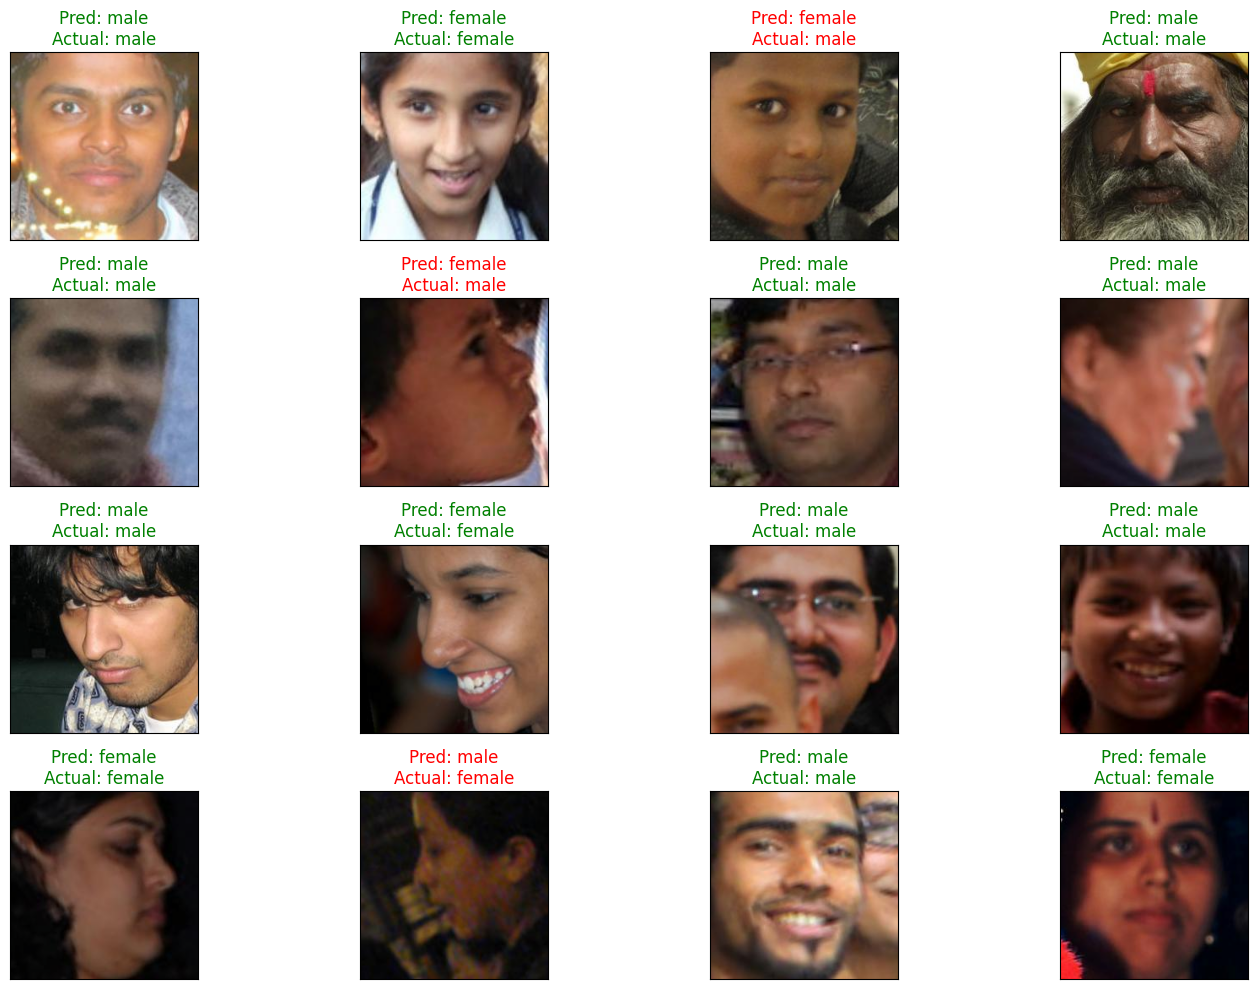

Displayed 16 images with predictions and actual labels.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Set the model to evaluation mode
model.eval()

# Get class names from the dataset
class_names = full_dataset.classes
print(f"Class names: {class_names}")

# Iterate through a few batches of the validation data loader
# We will only display images from the first batch for brevity
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Move images to the device
images = images.to(device)
labels = labels.to(device)


# Perform a forward pass to get the model's output
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Function to unnormalize images
def unnormalize(img):
    # Reverse normalization: img * std + mean
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# Display selected images along with their predicted and actual class labels
fig = plt.figure(figsize=(15, 10))
# Display up to 16 images from the batch
num_images_to_display = min(len(images), 16)

for i in range(num_images_to_display):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    # Unnormalize and display the image
    plt.imshow(unnormalize(images[i].cpu()))
    # Set the title with predicted and actual labels
    ax.set_title(f"Pred: {class_names[predicted[i]]}\nActual: {class_names[labels[i]]}",
                 color=("green" if predicted[i] == labels[i] else "red"))

plt.tight_layout()
plt.show()

print(f"Displayed {num_images_to_display} images with predictions and actual labels.")

## Save the trained model



In [ ]:
import torch

# 1. Define the path where you want to save the model file
model_save_path = 'gender_resnet18_model.pth'

# 2. Use torch.save() to save the model's state dictionary (model.state_dict()) to the defined path.
# We are saving the state_dict of the model that achieved the best validation accuracy.
torch.save(model.state_dict(), model_save_path)

# 3. Print a confirmation message indicating that the model has been saved and the location.
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to gender_resnet18_model.pth


## Download the trained model


In [ ]:
from google.colab import files

# Define the path of the model file to download
model_file_path = 'gender_resnet18_model.pth'

# Download the file
try:
  files.download(model_file_path)
  print(f"Successfully initiated download for {model_file_path}")
except Exception as e:
  print(f"An error occurred during download: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for gender_resnet18_model.pth


## Predict on a custom image

Saving 247.jpg to 247.jpg
Uploaded file: 247.jpg
Predicted class: female
Probabilities: tensor([1.0000e+00, 4.2130e-10], device='cuda:0')


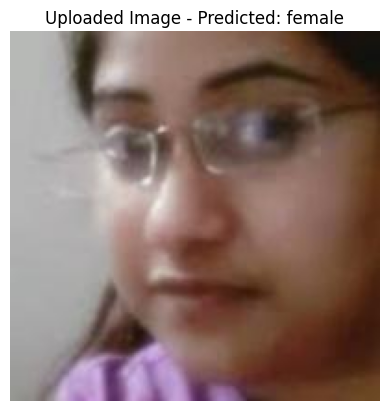

In [ ]:
from google.colab import files
from PIL import Image
import io

# Upload an image from your local machine
uploaded = files.upload()

# Assuming you upload only one file, get the filename
image_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {image_filename}")

# Read the image from the uploaded file
image_bytes = uploaded[image_filename]
img = Image.open(io.BytesIO(image_bytes)).convert('RGB')

# Apply the same transformations as the validation/test set
# We need to define the transforms again or reuse the val_test_transforms from before
# Assuming val_test_transforms is still available from the previous steps
# If not, you would need to redefine it here:
# val_test_transforms = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# Ensure val_test_transforms is defined. If not, define it here.
try:
    val_test_transforms
except NameError:
    print("val_test_transforms not found, defining it now.")
    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


input_tensor = val_test_transforms(img)
input_batch = input_tensor.unsqueeze(0) # Create a mini-batch as expected by the model

# Move the input to the same device as the model
input_batch = input_batch.to(device)

# Set the model to evaluation mode
model.eval()

# Perform inference
with torch.no_grad():
    output = model(input_batch)
    # The output are logits, apply softmax to get probabilities
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    _, predicted_class_index = torch.max(output, 1)

# Get the predicted class name
# Ensure class_names is available. If not, you would need to redefine it:
# class_names = full_dataset.classes # Assuming full_dataset is available

# Ensure class_names is defined. If not, define it here.
try:
    class_names
except NameError:
    print("class_names not found, defining it now.")
    # This assumes the directory structure 'gender_dataset/female' and 'gender_dataset/male'
    # If the structure is different, you'll need to adjust this.
    class_names = sorted(os.listdir('gender_dataset'))


predicted_class_name = class_names[predicted_class_index.item()]

print(f"Predicted class: {predicted_class_name}")
print(f"Probabilities: {probabilities}")

# Optional: Display the uploaded image
plt.imshow(img)
plt.title(f"Uploaded Image - Predicted: {predicted_class_name}")
plt.axis('off')
plt.show()